In [1]:
# Figure 10

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':15})
plt.rc('mathtext',**{'default':'regular'})
plt.rc('axes',linewidth=2)
%matplotlib inline
%config InlineBackend.figure_format='retina'


In [2]:
# GFDL data

dss1 = xr.open_dataset('GFDL/ocean_annual_z.static.nc')
xh1, yh1 = dss1.geolon, dss1.geolat

arch = 'GFDL/'
run1 = 'REF/'
run_BS = 'BS/'
run_BSV = 'BSV/'

f_MLD='1990-2009.ocean_monthly.MLD_003.nc'

ds_ref1=xr.open_dataset(arch + run1 + f_MLD)
ds_BS=xr.open_dataset(arch + run_BS + f_MLD)
ds_BSV=xr.open_dataset(arch + run_BSV + f_MLD)


In [3]:

gb=ds_ref1.MLD_003.groupby('time.year')
mld_ref1=gb.max(dim='time').mean(dim='year')

gb=ds_BS.MLD_003.groupby('time.year')
mld_BS=gb.max(dim='time').mean(dim='year')

gb=ds_BSV.MLD_003.groupby('time.year')
mld_BSV=gb.max(dim='time').mean(dim='year')


In [4]:
# CESM data

dss2 = xr.open_dataset('CESM/ocean_annual_z.static.nc')
xh2, yh2 = dss2.geolon, dss2.geolat

arch = 'CESM/'
run2 = 'REF/'
run_MBK = 'MBK/'
run_LBK = 'LBK/'

# I'm not sure if GFDL data are monthly mean or max
#f_MLD='0033-0052.ocean_monthly_mean.MLD.nc'
#f_MLD='0033-0052.ocean_monthly_max.MLD.nc'
f_MLD='0033-0052.ocean_monthly.MLD.nc'

ds_ref2=xr.open_dataset(arch + run2 + f_MLD)
ds_MBK=xr.open_dataset(arch + run_MBK + f_MLD)
ds_LBK=xr.open_dataset(arch + run_LBK + f_MLD)


In [5]:

gb=ds_ref2.mlotst.groupby('time.year')
mld_ref2=gb.max(dim='time').mean(dim='year')

gb=ds_MBK.mlotst.groupby('time.year')
mld_MBK=gb.max(dim='time').mean(dim='year')

gb=ds_LBK.mlotst.groupby('time.year')
mld_LBK=gb.max(dim='time').mean(dim='year')


/glade/derecho/scratch/chengz/tmp/ipykernel_11119/3266969134.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])  # leave room for bottom colorbars


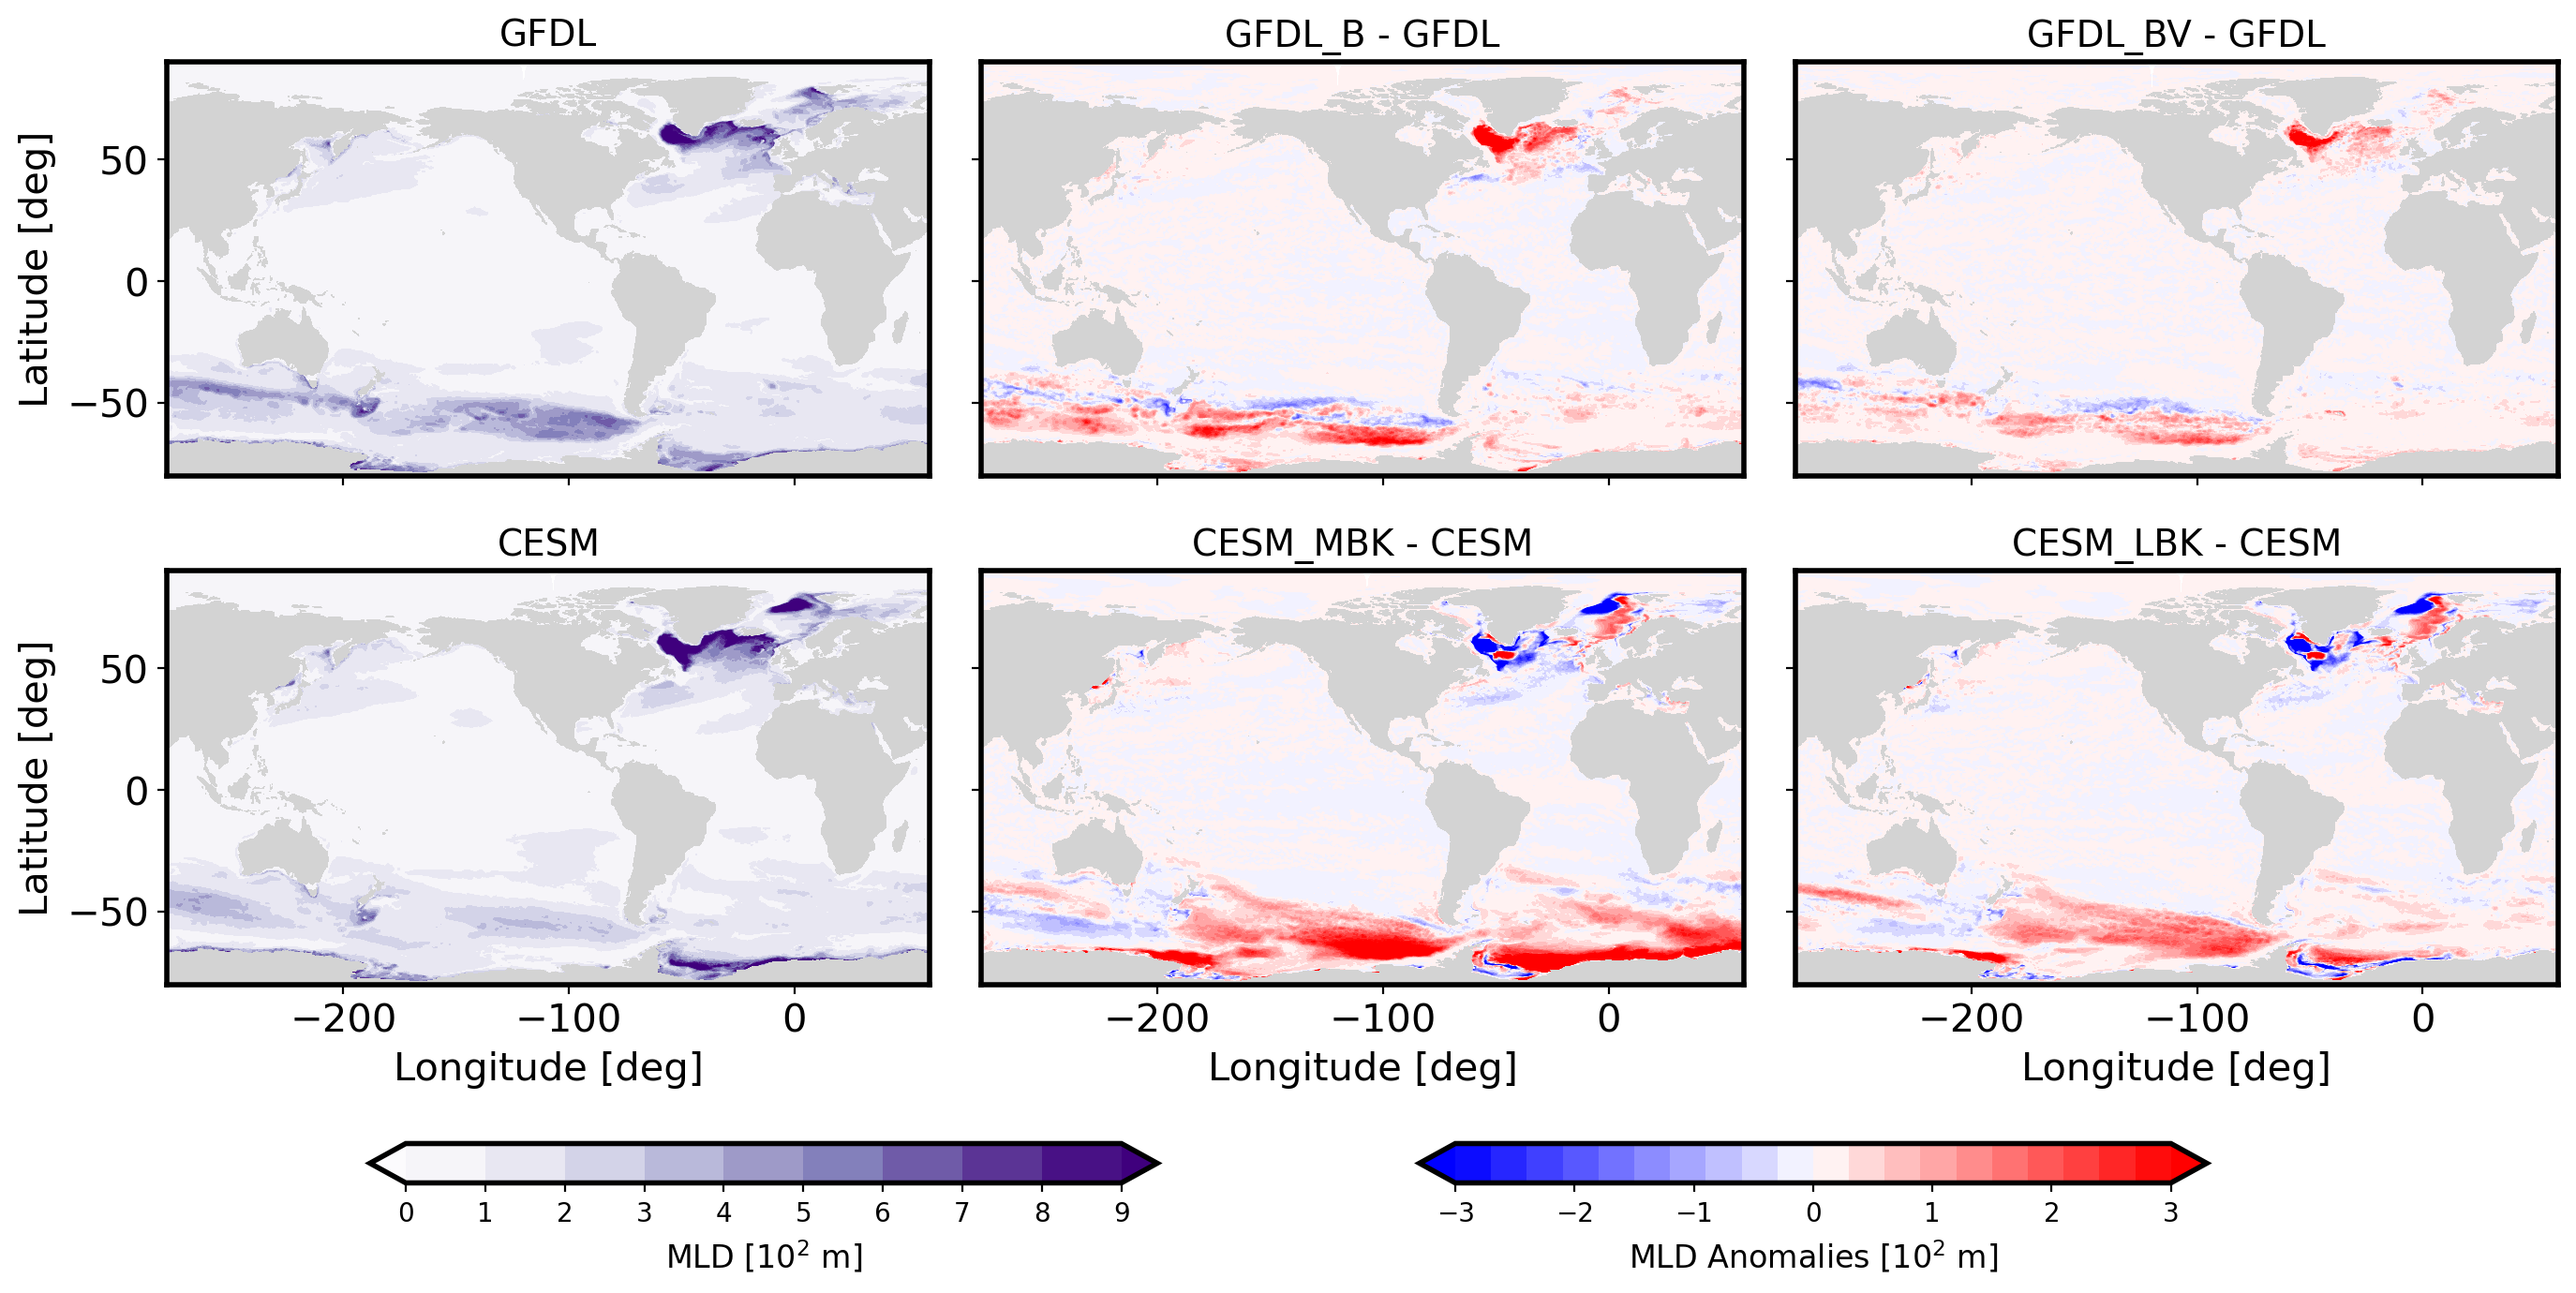

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

levels  = np.arange(0, 10, 1)          # for absolute MLD
alevels = np.arange(-3, 3.1, 0.3)      # for anomalies

datasets = [
    (mld_ref1[:,:]*1e-2, levels, "Purples", "GFDL"),
    ((mld_BS[:,:]-mld_ref1[:,:])*1e-2, alevels, "bwr", "GFDL_B - GFDL"),
    ((mld_BSV[:,:]-mld_ref1[:,:])*1e-2, alevels, "bwr", "GFDL_BV - GFDL"),
    (mld_ref2[:,:]*1e-2, levels, "Purples", "CESM"),
    ((mld_MBK[:,:]-mld_ref2[:,:])*1e-2, alevels, "bwr", "CESM_MBK - CESM"),
    ((mld_LBK[:,:]-mld_ref2[:,:])*1e-2, alevels, "bwr", "CESM_LBK - CESM"),
]

im_abs = None
im_anom = None

for i, ax in enumerate(axes.flat):
    field, levs, cmap, title = datasets[i]
    if i < 3:
        im = ax.contourf(xh1, yh1, field, levels=levs, cmap=cmap, extend='both')
        ax.contourf(xh1, yh1, dss1.wet, levels=[0, 0.001], colors='lightgray', extend='min')
    else:
        im = ax.contourf(xh2, yh2, field, levels=levs, cmap=cmap, extend='both')
        ax.contourf(xh2, yh2, dss2.wet, levels=[0, 0.001], colors='lightgray', extend='min')

    row, col = divmod(i, 3)
    ax.set_title(title, fontsize=14)

    # Axis formatting
    ax.set_xlim([-278, 60])
    ax.set_ylim([-80, 90])
    # ax.set_xticks(np.arange(-300, 80, 60))
    # ax.set_yticks(np.arange(-60, 100, 30))
    # ax.tick_params(labelsize=10)

    # Labels
    if col == 0:
        ax.set_ylabel("Latitude [deg]")

    if row == 1:
        ax.set_xlabel("Longitude [deg]")


    # Save handles for colorbars
    if col == 0:
        im_abs = im   # absolute MLD plots
    else:
        im_anom = im  # anomaly plots

# --- Colorbars at the bottom ---
cbar_ax1 = fig.add_axes([0.15, 0.08, 0.3, 0.03])  # left bottom
cbar1 = fig.colorbar(im_abs, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label(r"MLD [$10^{2}$ m]", fontsize=12)
cbar1.ax.tick_params(labelsize=10)

cbar_ax2 = fig.add_axes([0.55, 0.08, 0.3, 0.03])  # right bottom
cbar2 = fig.colorbar(im_anom, cax=cbar_ax2, orientation="horizontal",
                     ticks=np.arange(-3, 4, 1))
cbar2.set_label(r"MLD Anomalies [$10^{2}$ m]", fontsize=12)
cbar2.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0.12, 1, 1])  # leave room for bottom colorbars
#plt.savefig("Figures/GCM_MLD_mean.pdf", dpi=800)
#plt.savefig("Figures/GCM_MLD_max.pdf", dpi=800)
plt.savefig("Figures/GCM_MLD.pdf", dpi=800)
# plt.show()
